# Notebook 4: RL-DOHO vs standard feature-selection baselines (Rheumatic & Autoimmune Disease Dataset)

**Dataset:** Mahdi, M. F., Jahani, A., & Abd, D. H. (2025). *Diagnosis of rheumatic and autoimmune diseases dataset.* Data in Brief, 60, 111623. https://doi.org/10.1016/j.dib.2025.111623
These are 12,085 patient records from one hospital and three laboratories in Iraq (2019–2024), with 14 clinical and laboratory features and 7 classes.

**Same protocol as Notebook 1:** the same split, preprocessing (no leakage), fitness (0.99 × CV error of XGBoost + HistGradientBoosting with SMOTE inside folds, + 0.01 × feature fraction), seeds 0–9 and budget (12 agents × 20 iterations).

**Methods compared (11):**
- **DO, HO, DOHO, RL-DOHO:** reused from Notebook 1's saved results if available, otherwise run here.
- **Standard metaheuristics,** with the same encoding, initial population, budget and fitness:
  - **GA:** binary genetic algorithm.
  - **BPSO:** binary particle swarm.
  - **BGWO:** grey wolf optimizer.
- **Filter / embedded methods:** **LASSO** (L1 logistic regression), **mRMR** and **ReliefF**. Each ranks features on training data only, and the number of features is chosen by the same CV fitness.
- **All features:** no selection.

**Reported:**
- test accuracy, macro precision, macro recall and macro-F1, plus fitness and CV accuracy;
- number of tests selected;
- Friedman test with Holm-corrected Wilcoxon post-hoc tests (RL-DOHO vs each);
- a critical-difference diagram;
- each optimiser's own runtime;
- which lab tests each method selects.

In [1]:
# ================= 0. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import subprocess, sys
try:
    import xgboost, imblearn
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost", "imbalanced-learn"], check=True)

import os, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from scipy.stats import wilcoxon, friedmanchisquare
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [2]:
# ================= 1. CONFIG — change these =================
DATA_PATH = '/content/drive/MyDrive/Rheumatic and Autoimmune Disease Dataset.xlsx' if IN_COLAB \
            else 'Rheumatic and Autoimmune Disease Dataset.xlsx'
OUT_DIR   = '/content/drive/MyDrive/rl_doho_results' if IN_COLAB else 'rl_doho_results'

POP_SIZE   = 12        # agents per algorithm (same for all 4 -> equal evaluation budget)
MAX_ITER   = 20        # iterations per run
DETAIL_SEED = 42       # seed for the detailed single run (section 6)
SEEDS      = list(range(10))   # same seeds as Notebook 1
VERBOSE    = False     # True prints every iteration of every benchmark run (very long for 10 seeds)
RUN_ABLATION = True    # section 9: which RL-DOHO components matter

CV_FOLDS   = 3         # folds inside the fitness function
FIT_TREES  = 60        # trees per model inside fitness (cheap)
EVAL_TREES = 200       # trees per model for the final test evaluation
USE_SMOTE  = True      # SMOTE inside each CV fold / final training
ALPHA, BETA = 0.99, 0.01   # fitness = ALPHA*(1-acc) + BETA*(n_selected/n_features)
FITNESS_SUBSAMPLE = 4000   # stratified subset of train used ONLY inside fitness (~2s/eval). None = full train (~3.5s/eval)

os.makedirs(OUT_DIR, exist_ok=True)
ALGOS  = ["DO", "HO", "DOHO", "RL-DOHO"]
PROPOSED = "RL-DOHO"
COLORS = {"DO": "#2a78d6", "HO": "#eb6834", "DOHO": "#1baf7a", "RL-DOHO": "#eda100"}
STAG_TRIGGER = 2       # RL-DOHO: iterations without improvement before the bandit takes over
UCB_C        = 1.0     # UCB exploration constant
TABU_TENURE  = None    # None = remember every subset evaluated in the run (fine for 2^14 subsets); or an int, e.g. 10 iterations
TIE_EPS      = 0.001   # RL-DOHO parsimony tie-break: fitness within TIE_EPS (about CV noise) counts as a tie -> fewer features wins
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})
print("Output folder:", OUT_DIR)

Output folder: /content/drive/MyDrive/rl_doho_results


## 2. Load data and preprocess (no leakage)

In [3]:
df = pd.read_excel(DATA_PATH)
numeric_cols = ['Age', 'ESR', 'CRP', 'RF', 'Anti-CCP', 'C3', 'C4']
binary_cols  = ['Gender', 'HLA-B27', 'ANA', 'Anti-Ro', 'Anti-La', 'Anti-dsDNA', 'Anti-Sm']
FEATURES = numeric_cols + binary_cols
N_FEATURES = len(FEATURES)

# Binary columns -> 1/0 explicitly (LabelEncoder on a column with NaN filled by mode is fragile)
X = df[FEATURES].copy()
for c in binary_cols:
    X[c] = X[c].astype(str).str.strip().str.lower().map(
        {'male': 1, 'female': 0, 'positive': 1, 'negative': 0, 'yes': 1, 'no': 0})
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Disease'].astype(str))
CLASS_NAMES = list(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True)

# Imputation + scaling fitted on TRAIN only
num_imp = SimpleImputer(strategy='mean').fit(X_train[numeric_cols])
bin_imp = SimpleImputer(strategy='most_frequent').fit(X_train[binary_cols])
scaler  = StandardScaler().fit(num_imp.transform(X_train[numeric_cols]))
def prep(Xp):
    out = Xp.copy()
    out[numeric_cols] = scaler.transform(num_imp.transform(Xp[numeric_cols]))
    out[binary_cols]  = bin_imp.transform(Xp[binary_cols])
    return out.astype(float)
X_train, X_test = prep(X_train), prep(X_test)

# Optional stratified subsample used ONLY by the fitness function (speed)
if FITNESS_SUBSAMPLE and FITNESS_SUBSAMPLE < len(X_train):
    X_fit, _, y_fit, _ = train_test_split(X_train, y_train, train_size=FITNESS_SUBSAMPLE, stratify=y_train, random_state=0)
    X_fit = X_fit.reset_index(drop=True)
else:
    X_fit, y_fit = X_train, y_train

print("Rows:", len(df), "| features:", N_FEATURES, "| classes:", len(CLASS_NAMES))
print("Train:", X_train.shape, "Test:", X_test.shape, "Fitness set:", X_fit.shape)
print("Search space size: 2^%d - 1 = %d possible feature subsets" % (N_FEATURES, 2**N_FEATURES - 1))

Rows: 12085 | features: 14 | classes: 7
Train: (9668, 14) Test: (2417, 14) Fitness set: (4000, 14)
Search space size: 2^14 - 1 = 16383 possible feature subsets


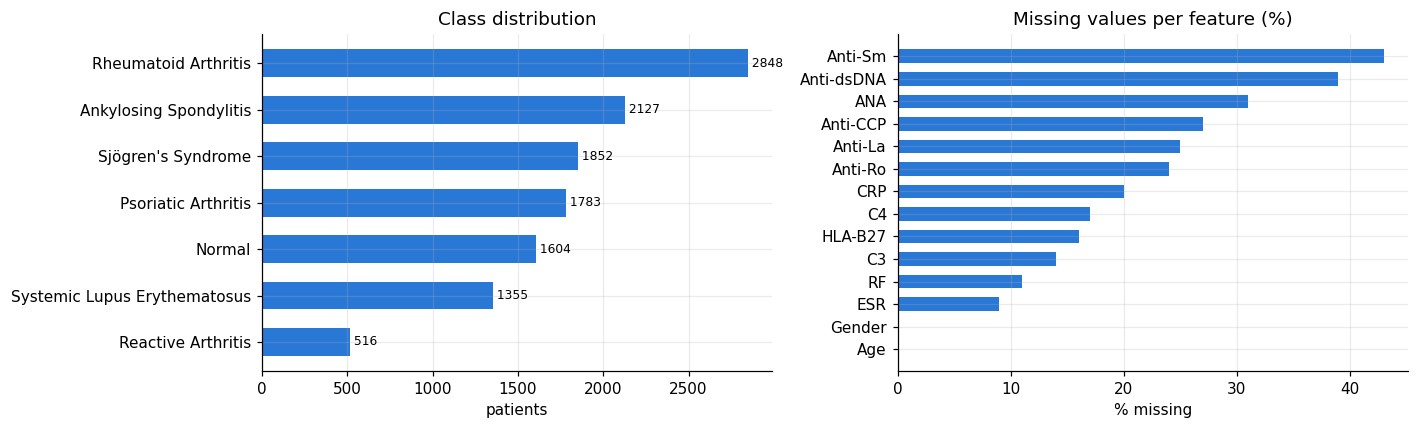

In [4]:
# EDA: class balance and missingness
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vc = df['Disease'].value_counts()
ax[0].barh(vc.index[::-1], vc.values[::-1], color="#2a78d6", height=0.6)
ax[0].set_title("Class distribution"); ax[0].set_xlabel("patients")
for i, v in enumerate(vc.values[::-1]): ax[0].text(v, i, f" {v}", va='center', fontsize=8)
miss = df[FEATURES].isna().mean().sort_values() * 100
ax[1].barh(miss.index, miss.values, color="#2a78d6", height=0.6)
ax[1].set_title("Missing values per feature (%)"); ax[1].set_xlabel("% missing")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/00_eda.png", bbox_inches='tight'); plt.show()

## 3. Fitness function (cached, CV with SMOTE inside each fold) and test evaluation

In [5]:
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

def make_models(n_trees):
    xgb = XGBClassifier(n_estimators=n_trees, max_depth=4, learning_rate=0.1, random_state=42,
                        tree_method='hist', verbosity=0, n_jobs=-1)
    hgb = HistGradientBoostingClassifier(max_iter=n_trees, max_depth=4, random_state=42)
    if USE_SMOTE:
        xgb = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', xgb)])
        hgb = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', hgb)])
    return xgb, hgb

CACHE_FILE = f"{OUT_DIR}/fitness_cache_{FIT_TREES}t_{CV_FOLDS}f_{int(USE_SMOTE)}s_{FITNESS_SUBSAMPLE}.pkl"
_cache = pickle.load(open(CACHE_FILE, 'rb')) if os.path.exists(CACHE_FILE) else {}
for _k, _v in _cache.items():   # re-score cached masks under the current ALPHA/BETA (accuracy is what's stored)
    _n = _k.count("1"); _v["fit"] = 1.0 if _n == 0 else ALPHA * (1 - _v["acc"]) + BETA * _n / len(_k)
print(f"Fitness cache loaded: {len(_cache)} masks already evaluated (re-scored with ALPHA={ALPHA}, BETA={BETA})")
COUNTER = {"calls": 0, "new": 0}

def mask_str(m): return ''.join(map(str, np.asarray(m).astype(int)))

def fitness_function(mask, X_tr=None, y_tr=None):
    # Deterministic, so caching is fair to every algorithm.
    COUNTER["calls"] += 1
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    Xs = X_fit.iloc[:, sel]
    xgb, hgb = make_models(FIT_TREES)
    acc = (cross_val_score(xgb, Xs, y_fit, cv=CV).mean() + cross_val_score(hgb, Xs, y_fit, cv=CV).mean()) / 2
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}
    COUNTER["new"] += 1
    if COUNTER["new"] % 10 == 0:                       # heartbeat: one dot per 10 new model trainings
        print(".", end="", flush=True)
        if COUNTER["new"] % 200 == 0: save_cache()
    return f

def save_cache(): pickle.dump(_cache, open(CACHE_FILE, 'wb'))

_test_cache = {}
def evaluate_on_test(mask, name="", verbose=True):
    key = mask_str(mask)
    if key not in _test_cache:
        idx = np.flatnonzero(mask)
        res = {}
        for mname, m in zip(["XGB", "HGB"], make_models(EVAL_TREES)):
            m.fit(X_train.iloc[:, idx], y_train)
            p = m.predict(X_test.iloc[:, idx])
            res[mname] = {"acc": accuracy_score(y_test, p), "f1": f1_score(y_test, p, average='macro'), "pred": p}
        res["acc"] = np.mean([res["XGB"]["acc"], res["HGB"]["acc"]])
        res["f1"]  = np.mean([res["XGB"]["f1"],  res["HGB"]["f1"]])
        _test_cache[key] = res
    r = _test_cache[key]
    if verbose:
        print(f"{name:8s} XGB acc={r['XGB']['acc']:.4f}  HGB acc={r['HGB']['acc']:.4f}  avg acc={r['acc']:.4f}  "
              f"macro-F1={r['f1']:.4f}  feats={int(np.sum(mask))}  mask={key}")
    return r

t = time.time(); f_all = fitness_function(np.ones(N_FEATURES, int))
print(f"One fitness evaluation took {time.time()-t:.1f}s  (fitness with ALL features = {f_all:.4f})")
print("Baseline with all features:")
_ = evaluate_on_test(np.ones(N_FEATURES, int), "ALL")

Fitness cache loaded: 4072 masks already evaluated (re-scored with ALPHA=0.99, BETA=0.01)
One fitness evaluation took 0.0s  (fitness with ALL features = 0.1884)
Baseline with all features:
ALL      XGB acc=0.8444  HGB acc=0.8349  avg acc=0.8397  macro-F1=0.8350  feats=14  mask=11111111111111


## 4. Shared helpers: binarization and the per-iteration logger

In [6]:
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def binarize(position): return (sigmoid(position) > 0.5).astype(int)

class IterLogger:
    # Records and prints every iteration of a run.
    def __init__(self, algo, seed, verbose=True):
        self.algo, self.seed, self.verbose = algo, seed, verbose
        self.rows, self.t0, self.seen = [], time.time(), set()
        if verbose:
            print(f"\n{'='*118}\n{algo}  | seed={seed} | pop={POP_SIZE} | iters={MAX_ITER}\n{'='*118}")
            print(f"{'iter':>4} | {'action':<14}| {'best':>7} {'genbest':>7} {'mean':>7} {'worst':>7} | "
                  f"{'#f':>2} | {'best mask':<{N_FEATURES}} | {'div':>5} | {'new':>3} | {'sec':>5}")

    def log(self, t, action, positions, fitness, best_fit, best_mask, reward=None):
        pm = np.array([binarize(p) for p in positions])
        fresh = {mask_str(m) for m in pm} - self.seen; new = len(fresh); self.seen |= fresh
        row = dict(iter=t, action=action, best=best_fit, gen_best=float(np.min(fitness)),
                   mean=float(np.mean(fitness)), worst=float(np.max(fitness)),
                   n_feats=int(best_mask.sum()), best_mask=best_mask.copy(),
                   pop_masks=pm,
                   diversity=float(np.mean(np.std(positions, axis=0))), new_evals=new,
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = f" r={reward:+.3f}" if reward is not None else ""
            print(f"{t:>4} | {action:<14}| {row['best']:.4f} {row['gen_best']:.4f} {row['mean']:.4f} {row['worst']:.4f} | "
                  f"{row['n_feats']:>2} | {mask_str(best_mask)} | {row['diversity']:.3f} | {new:>3} | {row['sec']:5.1f}{rw}")
        self.t0 = time.time()

    def finish(self, best_fit, best_mask):
        if self.verbose:
            sel = [FEATURES[i] for i in np.flatnonzero(best_mask)]
            print(f"    ('new' = subsets this run had not evaluated before; {len(self.seen)} distinct subsets in total)")
            print(f"--> {self.algo} done: best fitness={best_fit:.4f}, CV acc={_cache[mask_str(best_mask)]['acc']:.4f}, "
                  f"{len(sel)} features: {sel}")
        save_cache()
        return pd.DataFrame(self.rows)

## 5. The algorithms (original DO / HO update rules plus per-iteration logging)

In [7]:
def _init(rng, dim):
    positions = rng.uniform(-1, 1, size=(POP_SIZE, dim))
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    b = np.argmin(fitness)
    return positions, masks, fitness, positions[b].copy(), masks[b].copy(), fitness[b]

def _evaluate_and_update(positions, fitness, best_position, best_mask, best_fitness, t):
    # Elitism (worst of previous generation gets the best), evaluate, update the global best.
    worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1
    positions[worst_idx] = best_position.copy()
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    g = np.argmin(fitness); improved = fitness[g] < best_fitness
    if improved:
        best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
    return masks, fitness, best_position, best_mask, best_fitness, improved

# ---------------- DO ----------------
def dandelion_optimizer(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "rising" if progress < 0.4 else ("descending" if progress < 0.8 else "landing")
        for i in range(POP_SIZE):
            if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
            elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:                positions[i] += rng.normal(0, 0.1, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, phase, positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- HO ----------------
def hippopotamus_optimization(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("HO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        n_mv = [0, 0, 0]
        for i in range(POP_SIZE):
            r = rng.random()
            if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6; n_mv[0] += 1
            elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i]); n_mv[1] += 1
            else:         positions[i] += rng.normal(0, 0.6, dim); n_mv[2] += 1
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"mv{n_mv[0]}/df{n_mv[1]}/ev{n_mv[2]}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- Fixed DOHO ----------------
def doho_fixed(seed=42, verbose=True, switch_point=0.5):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DOHO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "DO" if progress <= switch_point else "HO"
        for i in range(POP_SIZE):
            if phase == "DO":
                if progress < switch_point * 0.6: positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                else: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"phase {phase}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

In [8]:
# ---------------- Previous RL-DOHO (Q-learning controller, v10): used only in the ablation ----------------
ACTION_NAMES = {0: "DO", 1: "HO", 2: "PERTURB", 3: "RESTART"}

class QLearningController:
    def __init__(self, n_actions=4, alpha=0.5, gamma=0.5, epsilon=0.3, epsilon_decay=0.85, seed=42):
        self.rng = np.random.default_rng(seed); self.q_table = {}
        self.alpha, self.gamma, self.epsilon, self.epsilon_decay, self.n_actions = alpha, gamma, epsilon, epsilon_decay, n_actions
    def get_state(self, positions, stagnation, progress):
        div = np.mean(np.std(positions, axis=0))
        return (int(div >= 0.8), int(stagnation >= 3), int(progress >= 0.5))
    def _q(self, s):
        if s not in self.q_table: self.q_table[s] = np.zeros(self.n_actions)
        return self.q_table[s]
    def choose_action(self, state):
        q = self._q(state)
        if self.rng.random() < self.epsilon: return int(self.rng.integers(0, self.n_actions)), "explore"
        best = np.flatnonzero(q == q.max())                 # random tie-break, not always action 0
        return int(self.rng.choice(best)), "greedy"
    def update(self, s, a, r, s2):
        q = self._q(s); q[a] += self.alpha * (r + self.gamma * np.max(self._q(s2)) - q[a])
    def decay_epsilon(self): self.epsilon = max(0.05, self.epsilon * self.epsilon_decay)

def rl_doho_qlearning(seed=42, verbose=True, perturb_frac=0.15, controller=None, name="RL-DOHO (Q-learning)"):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = controller(seed) if controller else QLearningController(seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    stagnation = 0; k = max(1, int(round(dim * perturb_frac)))
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        state = agent.get_state(positions, stagnation, progress)
        action, how = agent.choose_action(state)
        order = np.argsort(fitness); worst_half = set(order[POP_SIZE // 2:])
        prev_top = np.mean(np.sort(fitness)[:POP_SIZE // 2]); prev_best = best_fitness
        for i in range(POP_SIZE):
            if action == 0:                                   # DO move
                if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
                else:                positions[i] += rng.normal(0, 0.1, dim)
            elif action == 1:                                 # HO move
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            elif i in worst_half:                             # disruptive actions only hit the worst half
                if action == 2:                               # flip k bits of the best solution
                    p = best_position.copy(); d = rng.choice(dim, k, replace=False)
                    p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); positions[i] = p
                else:                                         # restart
                    positions[i] = rng.uniform(-1, 1, dim)
            else:                                             # good half keeps exploiting
                positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            positions[i] = np.clip(positions[i], -3, 3)
        positions[order[-1]] = best_position.copy()          # elitism
        masks = np.array([binarize(p) for p in positions])
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness:
            best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy(); stagnation = 0
        else:
            stagnation += 1
        new_top = np.mean(np.sort(fitness)[:POP_SIZE // 2])
        reward = 100 * (prev_best - best_fitness) + 10 * (prev_top - new_top)
        agent.update(state, action, reward, agent.get_state(positions, stagnation, min((t + 1) / MAX_ITER, 1.0)))
        agent.decay_epsilon()
        L.log(t, f"{ACTION_NAMES[action]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["rl_action"] = ["init"] + [a.split("(")[0] for a in hist["action"][1:]]
    hist.attrs["q_table"] = {s: q.copy() for s, q in agent.q_table.items()}
    return best_mask, best_fitness, hist

RUNNERS = {"DO": dandelion_optimizer, "HO": hippopotamus_optimization, "DOHO": doho_fixed}

In [9]:
# ---------------- RL-DOHO (proposed): DO + HO + UCB bandit controller ----------------
ARMS = ("PERTURB", "RESTART", "DO", "HO")

class UCBBandit:
    # UCB1 multi-armed bandit (single-state reinforcement learning). Rewards are in [0, 1].
    def __init__(self, n_arms=3, c=1.0, seed=42):
        self.rng = np.random.default_rng(seed); self.c = c
        self.n = np.zeros(n_arms); self.value = np.zeros(n_arms)
    def choose(self):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "init"
        ucb = self.value + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "ucb"
    def update(self, arm, r):
        self.n[arm] += 1; self.value[arm] += (r - self.value[arm]) / self.n[arm]

class RandomArm(UCBBandit):              # ablation: same trigger, arm chosen at random
    def choose(self): return int(self.rng.integers(len(self.n))), "random"

class FixedArm(UCBBandit):               # ablation: same trigger, always the same arm
    def __init__(self, arm, seed, n_arms=4): super().__init__(n_arms=n_arms, seed=seed); self.arm = arm
    def choose(self): return self.arm, "fixed"

def _do_move(rng, pos, best_position, progress, dim):
    # DO's movement equations, unchanged
    if progress < 0.4:   pos = pos + rng.normal(0, 1, dim) * (1 - progress)
    elif progress < 0.8: pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.5
    else:                pos = pos + rng.normal(0, 0.1, dim)
    return np.clip(pos, -3, 3)

def _ho_move(rng, pos, best_position, dim):
    # HO's movement equations, unchanged
    r = rng.random()
    if r < 0.5:   pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.6
    elif r < 0.8: pos = pos + rng.uniform(0.2, 0.7) * (best_position - pos)
    else:         pos = pos + rng.normal(0, 0.6, dim)
    return np.clip(pos, -3, 3)

def rl_doho(seed=42, verbose=True, bandit=None, name="RL-DOHO", arms=ARMS, k_max=3, tabu_tries=20, tie_eps=None):
    tie_eps = TIE_EPS if tie_eps is None else tie_eps
    def better(f, nf, bf, bnf):   # strictly better, or a tie within tie_eps with fewer features
        return f < bf - tie_eps or (abs(f - bf) <= tie_eps and (nf < bnf or (nf == bnf and f < bf)))
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = bandit(seed) if bandit else UCBBandit(n_arms=len(arms), c=UCB_C, seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    tabu = {mask_str(m): 0 for m in masks}            # subset -> last iteration it was visited
    def is_tabu(key, t): return key in tabu and (TABU_TENURE is None or t - tabu[key] <= TABU_TENURE)
    def tabu_draw(make, t):
        for _ in range(tabu_tries):
            p = make(); key = mask_str(binarize(p))
            if not is_tabu(key, t): break
        tabu[key] = t                                  # reserve it so two agents don't draw the same subset
        return np.clip(p, -3, 3)
    stagnation = 0

    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        prev_best, prev_median = best_fitness, float(np.median(fitness))
        order = np.argsort(fitness); worst_half = order[POP_SIZE // 2:]
        if stagnation < STAG_TRIGGER:                  # ---- improving: plain DO exploration
            arm, how = None, None
            for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
            touched = np.arange(POP_SIZE)
        else:                                          # ---- stalled: the bandit picks an arm
            arm, how = agent.choose()
            if arms[arm] == "DO":
                for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                touched = np.arange(POP_SIZE)
            elif arms[arm] == "HO":
                for i in range(POP_SIZE): positions[i] = _ho_move(rng, positions[i], best_position, dim)
                touched = np.arange(POP_SIZE)
            else:
                for i in order[:POP_SIZE // 2]:        # better half keeps DO's movement
                    positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                for i in worst_half:
                    if arms[arm] == "PERTURB":     # flip 1..k_max features of the best subset
                        def make():
                            p = best_position.copy(); k = int(rng.integers(1, k_max + 1))
                            d = rng.choice(dim, k, replace=False)
                            p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); return p
                    else:                              # RESTART: fresh random subset
                        make = lambda: rng.uniform(-1, 1, dim)
                    positions[i] = tabu_draw(make, t)
                touched = worst_half
        worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1     # elitism, same rule as DO
        positions[worst_idx] = best_position.copy()
        masks = np.array([binarize(p) for p in positions])
        for m in masks: tabu[mask_str(m)] = t
        fitness = np.array([fitness_function(m) for m in masks])
        improved = False
        for g in np.argsort(fitness):                  # best candidate under the parsimony rule
            if better(fitness[g], masks[g].sum(), best_fitness, best_mask.sum()):
                best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
                improved = True
        stagnation = 0 if improved else stagnation + 1
        if arm is None:
            L.log(t, "DO-explore", positions, fitness, best_fitness, best_mask)
        else:
            # reward: 1 for a new global best, otherwise up to 0.2 for the share of the arm's
            # candidates that beat the previous population median
            touched = [i for i in touched if i != worst_idx]
            share = np.mean([fitness[i] < prev_median for i in touched]) if touched else 0.0
            reward = 1.0 if improved else 0.2 * share
            agent.update(arm, reward)
            L.log(t, f"{arms[arm]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["arm"] = ["init"] + [("EXPLORE" if a == "DO-explore" else a.split("(")[0]) for a in hist["action"][1:]]
    hist.attrs["pulls"] = agent.n.copy(); hist.attrs["arm_value"] = agent.value.copy(); hist.attrs["arm_names"] = list(arms)
    return best_mask, best_fitness, hist

RUNNERS["RL-DOHO"] = rl_doho
print("Algorithms ready:", list(RUNNERS))

Algorithms ready: ['DO', 'HO', 'DOHO', 'RL-DOHO']


## 6. Baseline methods

In [10]:
# ================= Baseline metaheuristics =================
# Same encoding (continuous position -> sigmoid > 0.5), same initial population (_init), same population size,
# same number of iterations, and the same fitness function as DO / HO / DOHO / RL-DOHO -> equal evaluation budget.

def genetic_algorithm(seed=42, verbose=True, pc=0.9, tour=3):
    # Binary GA: tournament selection, uniform crossover, bit-flip mutation (rate 1/D), elitism of 1.
    rng = np.random.default_rng(seed); dim = N_FEATURES; pm = 1.0 / dim
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("GA", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        def pick():
            idx = rng.choice(POP_SIZE, tour, replace=False); return masks[idx[np.argmin(fitness[idx])]]
        new = [best_mask.copy()]
        while len(new) < POP_SIZE:
            p1, p2 = pick(), pick()
            if rng.random() < pc:
                cm = rng.random(dim) < 0.5; kids = [np.where(cm, p1, p2), np.where(cm, p2, p1)]
            else:
                kids = [p1.copy(), p2.copy()]
            for c in kids:
                c = np.where(rng.random(dim) < pm, 1 - c, c)
                if len(new) < POP_SIZE: new.append(c)
        masks = np.array(new).astype(int); positions = masks * 2.0 - 1.0
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness: best_fitness, best_mask = fitness[g], masks[g].copy()
        L.log(t, "generation", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

def binary_pso(seed=42, verbose=True, c1=2.0, c2=2.0, vmax=6.0):
    # Binary PSO (Kennedy & Eberhart 1997): sigmoid transfer of velocities, inertia 0.9 -> 0.4.
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    X = masks.copy(); V = rng.uniform(-1, 1, (POP_SIZE, dim))
    pbest, pbest_f = X.copy(), fitness.copy()
    L = IterLogger("BPSO", seed, verbose); L.log(0, "init", X * 2.0 - 1.0, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        w = 0.9 - 0.5 * t / MAX_ITER
        r1, r2 = rng.random((POP_SIZE, dim)), rng.random((POP_SIZE, dim))
        V = np.clip(w * V + c1 * r1 * (pbest - X) + c2 * r2 * (best_mask - X), -vmax, vmax)
        X = (rng.random((POP_SIZE, dim)) < 1 / (1 + np.exp(-V))).astype(int)
        fitness = np.array([fitness_function(m) for m in X])
        imp = fitness < pbest_f; pbest[imp] = X[imp]; pbest_f[imp] = fitness[imp]
        g = np.argmin(fitness)
        if fitness[g] < best_fitness: best_fitness, best_mask = fitness[g], X[g].copy()
        L.log(t, f"w={w:.2f}", X * 2.0 - 1.0, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

def binary_gwo(seed=42, verbose=True):
    # Grey Wolf Optimizer (Mirjalili et al. 2014) on continuous positions, binarised like DO/HO (sigmoid > 0.5).
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("BGWO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        a = 2 - 2 * t / MAX_ITER
        leaders = positions[np.argsort(fitness)[:3]].copy()
        new = np.empty_like(positions)
        for i in range(POP_SIZE):
            xs = []
            for Lp in leaders:
                A = 2 * a * rng.random(dim) - a; C = 2 * rng.random(dim)
                xs.append(Lp - A * np.abs(C * Lp - positions[i]))
            new[i] = np.clip(np.mean(xs, axis=0), -3, 3)
        positions = new
        masks = np.array([binarize(p) for p in positions])
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness: best_fitness, best_mask = fitness[g], masks[g].copy()
        L.log(t, f"a={a:.2f}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ================= Filter / embedded baselines =================
# Each ranks features on the TRAINING data only; the number of features k is then chosen
# by the same fitness function (CV on training data), so no test data is used.
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

def rank_lasso(X, y, seed, k_max):
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12)
    m = LogisticRegression(penalty="l1", solver="saga", C=0.5, max_iter=3000, random_state=seed).fit(Xs, y)
    return np.argsort(-np.abs(m.coef_).sum(0), kind="stable")

def rank_mrmr(X, y, seed, k_max):
    # mRMR (difference form): relevance = mutual information with the class; redundancy = mean |correlation| with selected features
    rel = mutual_info_classif(X, y, random_state=seed)
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12); n = len(Xs)
    sel = [int(np.argmax(rel))]; red = np.zeros(X.shape[1])
    for _ in range(min(k_max, X.shape[1]) - 1):
        red += np.abs(Xs.T @ Xs[:, sel[-1]]) / n
        score = rel - red / len(sel); score[sel] = -np.inf
        sel.append(int(np.argmax(score)))
    rest = [j for j in np.argsort(-rel) if j not in set(sel)]
    return np.array(sel + rest)

def rank_relieff(X, y, seed, k_max, m=500, k=10):
    # ReliefF (Kononenko 1994) with m sampled instances and k nearest hits/misses per class
    rng = np.random.default_rng(seed)
    Xn = (X - X.min(0)) / (X.max(0) - X.min(0) + 1e-12)
    classes, counts = np.unique(y, return_counts=True); prior = dict(zip(classes, counts / len(y)))
    idx = rng.choice(len(Xn), min(m, len(Xn)), replace=False); W = np.zeros(Xn.shape[1])
    for i in idx:
        d = np.abs(Xn - Xn[i]).sum(1); d[i] = np.inf
        for c in classes:
            cand = np.flatnonzero(y == c); cand = cand[cand != i]
            if len(cand) == 0: continue
            nn = cand[np.argsort(d[cand])[:k]]
            diff = np.abs(Xn[nn] - Xn[i]).mean(0)
            if c == y[i]: W -= diff / len(idx)
            else: W += prior[c] / (1 - prior[y[i]]) * diff / len(idx)
    return np.argsort(-W, kind="stable")

RANKERS = {"LASSO": rank_lasso, "mRMR": rank_mrmr, "ReliefF": rank_relieff}

def k_grid(D):
    if D <= 40: return list(range(1, D + 1))
    return sorted({k for k in [5, 10, 20, 50, 100, 200, 500, 1000, 2000, D] if k <= D})

def run_filter(name, seed, X_rank, y_rank):
    # Returns (mask, fitness, chosen k). "All features" keeps everything.
    D = N_FEATURES
    if name == "All features":
        m = np.ones(D, int); return m, fitness_function(m), D
    ks = k_grid(D); order = RANKERS[name](X_rank, y_rank, seed, max(ks))
    best = None
    for k in ks:
        m = np.zeros(D, int); m[order[:k]] = 1
        f = fitness_function(m)
        if best is None or f < best[1] - 1e-12: best = (m, f, k)
    return best

BASELINE_RUNNERS = {"GA": genetic_algorithm, "BPSO": binary_pso, "BGWO": binary_gwo}
FILTERS = ["LASSO", "mRMR", "ReliefF", "All features"]
print("Baselines ready:", list(BASELINE_RUNNERS), "+", FILTERS)

Baselines ready: ['GA', 'BPSO', 'BGWO'] + ['LASSO', 'mRMR', 'ReliefF', 'All features']


## 7. Benchmark: 11 methods × 10 seeds (resumable; reuses Notebook 1 results and fitness cache)
Each run is saved as soon as it finishes. A dot is printed every 10 new model trainings.

In [11]:
from sklearn.metrics import precision_score, recall_score
SEARCH  = ALGOS + list(BASELINE_RUNNERS)
METHODS = SEARCH + FILTERS
PREV_FILE = f"{OUT_DIR}/final_runs_p{POP_SIZE}_i{MAX_ITER}_a{ALPHA}_st{STAG_TRIGGER}_tie{TIE_EPS}.pkl"   # Notebook 1
BASE_FILE = f"{OUT_DIR}/baselines_runs_p{POP_SIZE}_i{MAX_ITER}_a{ALPHA}_tie{TIE_EPS}.pkl"
PREV = pickle.load(open(PREV_FILE, "rb")) if os.path.exists(PREV_FILE) else {}
runs = pickle.load(open(BASE_FILE, "rb")) if os.path.exists(BASE_FILE) else {}
print(f"Notebook 1 results found: {sum(1 for k in PREV if k[0] in ALGOS)} runs | baseline runs already done: {len(runs)}")

def test_metrics(mask):
    r = evaluate_on_test(mask, verbose=False)
    prec = np.mean([precision_score(y_test, r[m]["pred"], average="macro", zero_division=0) for m in ("XGB", "HGB")])
    rec  = np.mean([recall_score(y_test, r[m]["pred"], average="macro", zero_division=0) for m in ("XGB", "HGB")])
    return {"test_acc": r["acc"], "test_prec": prec, "test_rec": rec, "test_f1": r["f1"]}

X_rank, y_rank = X_fit.values, y_fit          # filters rank features on the (training) fitness data only
t_start = time.time()
for s in SEEDS:
    for a in METHODS:
        if (a, s) in runs: continue
        info = ""
        if a in ALGOS and (a, s) in PREV:
            m, f = PREV[(a, s)]["mask"], PREV[(a, s)]["fit"]; info = "reused from Notebook 1"
        elif a in ALGOS:
            m, f, _ = RUNNERS[a](seed=s, verbose=VERBOSE)
        elif a in BASELINE_RUNNERS:
            m, f, _ = BASELINE_RUNNERS[a](seed=s, verbose=VERBOSE)
        else:
            m, f, k = run_filter(a, s, X_rank, y_rank); info = f"k={k}"
        m = np.asarray(m).astype(int)
        runs[(a, s)] = {"mask": m, "fit": float(f), "cv_acc": _cache[mask_str(m)]["acc"], "n_feats": int(m.sum()), **test_metrics(m)}
        pickle.dump(runs, open(BASE_FILE, "wb"))
        r = runs[(a, s)]
        print(f"\n  [{time.strftime('%H:%M:%S')}] seed {s} {a:12s} fit={r['fit']:.4f} acc={r['test_acc']:.4f} "
              f"prec={r['test_prec']:.4f} rec={r['test_rec']:.4f} f1={r['test_f1']:.4f} tests={r['n_feats']} {info}", flush=True)
    save_cache()
print(f"\nBenchmark complete ({time.time() - t_start:.0f}s).")

Notebook 1 results found: 40 runs | baseline runs already done: 5
...........
  [06:36:07] seed 0 BPSO         fit=0.1820 acc=0.8465 prec=0.8489 rec=0.8456 f1=0.8400 tests=10 
.
  [06:37:02] seed 0 BGWO         fit=0.1822 acc=0.8461 prec=0.8402 rec=0.8474 f1=0.8428 tests=11 
.
  [06:37:28] seed 0 LASSO        fit=0.1868 acc=0.8492 prec=0.8454 rec=0.8528 f1=0.8481 tests=12 k=12

  [06:37:43] seed 0 mRMR         fit=0.1844 acc=0.8500 prec=0.8436 rec=0.8530 f1=0.8473 tests=11 k=11

  [06:37:56] seed 0 ReliefF      fit=0.1868 acc=0.8492 prec=0.8454 rec=0.8528 f1=0.8481 tests=12 k=12

  [06:37:56] seed 0 All features fit=0.1884 acc=0.8397 prec=0.8349 rec=0.8370 f1=0.8350 tests=14 k=14

  [06:38:03] seed 1 DO           fit=0.1929 acc=0.8362 prec=0.8292 rec=0.8328 f1=0.8296 tests=11 reused from Notebook 1

  [06:38:10] seed 1 HO           fit=0.1980 acc=0.8287 prec=0.8256 rec=0.8315 f1=0.8253 tests=8 reused from Notebook 1

  [06:38:10] seed 1 DOHO         fit=0.1929 acc=0.8362 prec=0.8292 re

## 8. Results table (mean ± std over 10 seeds)

In [12]:
res = pd.DataFrame([{"method": a, "seed": s, **{k: v for k, v in r.items() if k != "mask"}}
                    for (a, s), r in runs.items() if a in METHODS and s in SEEDS])
res.to_csv(f"{OUT_DIR}/baselines_per_run.csv", index=False)
res["rank_fit"] = res.groupby("seed")["fit"].rank()
res["rank_acc"] = res.groupby("seed")["test_acc"].rank(ascending=False)
cols = ["fit", "cv_acc", "test_acc", "test_prec", "test_rec", "test_f1", "n_feats"]
g = res.groupby("method")
tab = pd.concat({c: g[c].mean().map("{:.4f}".format) + " ± " + g[c].std().map("{:.4f}".format) for c in cols}, axis=1)
tab["n_feats"] = g["n_feats"].mean().round(1).astype(str) + " ± " + g["n_feats"].std().round(1).astype(str)
tab["avg rank (fitness)"] = g["rank_fit"].mean().round(2); tab["avg rank (test acc)"] = g["rank_acc"].mean().round(2)
tab = tab.reindex(g["rank_fit"].mean().sort_values().index)
tab.to_csv(f"{OUT_DIR}/baselines_summary.csv")
tab

,fit,cv_acc,test_acc,test_prec,test_rec,test_f1,n_feats,avg rank (fitness),avg rank (test acc)
method,,,,,,,,,
GA,0.1821 ± 0.0002,0.8236 ± 0.0006,0.8445 ± 0.0035,0.8449 ± 0.0078,0.8444 ± 0.0020,0.8386 ± 0.0024,10.4 ± 0.8,1.90,6.00
BPSO,0.1828 ± 0.0010,0.8233 ± 0.0009,0.8454 ± 0.0032,0.8432 ± 0.0063,0.8463 ± 0.0037,0.8406 ± 0.0042,11.0 ± 1.1,2.85,6.05
RL-DOHO,0.1845 ± 0.0038,0.8208 ± 0.0042,0.8434 ± 0.0076,0.8434 ± 0.0106,0.8431 ± 0.0075,0.8379 ± 0.0082,9.9 ± 0.7,4.55,5.85
mRMR,0.1848 ± 0.0021,0.8219 ± 0.0024,0.8451 ± 0.0045,0.8386 ± 0.0044,0.8467 ± 0.0051,0.8415 ± 0.0047,11.9 ± 1.3,5.30,5.20
ReliefF,0.1854 ± 0.0012,0.8210 ± 0.0008,0.8497 ± 0.0004,0.8443 ± 0.0010,0.8529 ± 0.0001,0.8476 ± 0.0004,11.4 ± 0.5,6.10,1.40
DO,0.1871 ± 0.0061,0.8185 ± 0.0065,0.8414 ± 0.0093,0.8409 ± 0.0133,0.8413 ± 0.0078,0.8365 ± 0.0085,10.3 ± 1.2,6.40,6.60
BGWO,0.1894 ± 0.0116,0.8162 ± 0.0123,0.8385 ± 0.0130,0.8381 ± 0.0119,0.8369 ± 0.0177,0.8328 ± 0.0157,10.4 ± 1.4,6.75,7.55
HO,0.1880 ± 0.0071,0.8177 ± 0.0081,0.8379 ± 0.0097,0.8330 ± 0.0099,0.8389 ± 0.0096,0.8332 ± 0.0105,10.6 ± 1.5,7.20,9.00
LASSO,0.1868 ± 0.0000,0.8200 ± 0.0000,0.8492 ± 0.0000,0.8454 ± 0.0000,0.8528 ± 0.0000,0.8481 ± 0.0000,12.0 ± 0.0,7.60,2.10


## 9. Statistics: Friedman test + Holm-corrected Wilcoxon post-hoc (RL-DOHO vs each method)

In [13]:
def holm(pvals):
    p = np.asarray(pvals, float); order = np.argsort(p); m = len(p); adj = np.empty(m); run = 0.0
    for i, j in enumerate(order):
        run = max(run, min(1.0, (m - i) * p[j])); adj[j] = run
    return adj

for metric, lower_better, label in [("fit", True, "fitness"), ("test_acc", False, "test accuracy"), ("test_f1", False, "macro-F1")]:
    P = res.pivot(index="seed", columns="method", values=metric)[METHODS]
    fr = friedmanchisquare(*[P[c] for c in METHODS])
    print(f"\n=== {label}: Friedman chi2={fr.statistic:.2f}, p={fr.pvalue:.2e} ===")
    others = [c for c in METHODS if c != PROPOSED]; raw, rows = [], []
    for c in others:
        d = P[PROPOSED] - P[c]
        if not lower_better: d = -d
        try: p = wilcoxon(P[PROPOSED], P[c], zero_method="zsplit").pvalue
        except ValueError: p = 1.0
        raw.append(p); rows.append((c, int(np.sum(d < -1e-12)), int(np.sum(np.abs(d) <= 1e-12)), int(np.sum(d > 1e-12)), d.mean()))
    adj = holm(raw)
    for (c, w, t_, l, md_), p, pa in zip(rows, raw, adj):
        print(f"  RL-DOHO vs {c:12s} W/T/L={w}/{t_}/{l}  mean diff={-md_ if not lower_better else md_:+.4f}  "
              f"p={p:.4f}  Holm p={pa:.4f}  {'SIGNIFICANT' if pa < 0.05 else ''}")


=== fitness: Friedman chi2=45.55, p=1.73e-06 ===
  RL-DOHO vs DO           W/T/L=5/4/1  mean diff=-0.0026  p=0.1562  Holm p=1.0000  
  RL-DOHO vs HO           W/T/L=7/0/3  mean diff=-0.0035  p=0.1934  Holm p=1.0000  
  RL-DOHO vs DOHO         W/T/L=7/1/2  mean diff=-0.0037  p=0.0742  Holm p=0.5938  
  RL-DOHO vs GA           W/T/L=2/1/7  mean diff=+0.0025  p=0.0391  Holm p=0.3516  
  RL-DOHO vs BPSO         W/T/L=3/1/6  mean diff=+0.0017  p=0.3477  Holm p=1.0000  
  RL-DOHO vs BGWO         W/T/L=7/0/3  mean diff=-0.0049  p=0.2754  Holm p=1.0000  
  RL-DOHO vs LASSO        W/T/L=7/0/3  mean diff=-0.0023  p=0.1504  Holm p=1.0000  
  RL-DOHO vs mRMR         W/T/L=7/0/3  mean diff=-0.0003  p=0.6953  Holm p=1.0000  
  RL-DOHO vs ReliefF      W/T/L=7/0/3  mean diff=-0.0009  p=0.2188  Holm p=1.0000  
  RL-DOHO vs All features W/T/L=9/0/1  mean diff=-0.0039  p=0.0098  Holm p=0.0977  

=== test accuracy: Friedman chi2=53.96, p=4.95e-08 ===
  RL-DOHO vs DO           W/T/L=4/4/2  mean diff=+0.00

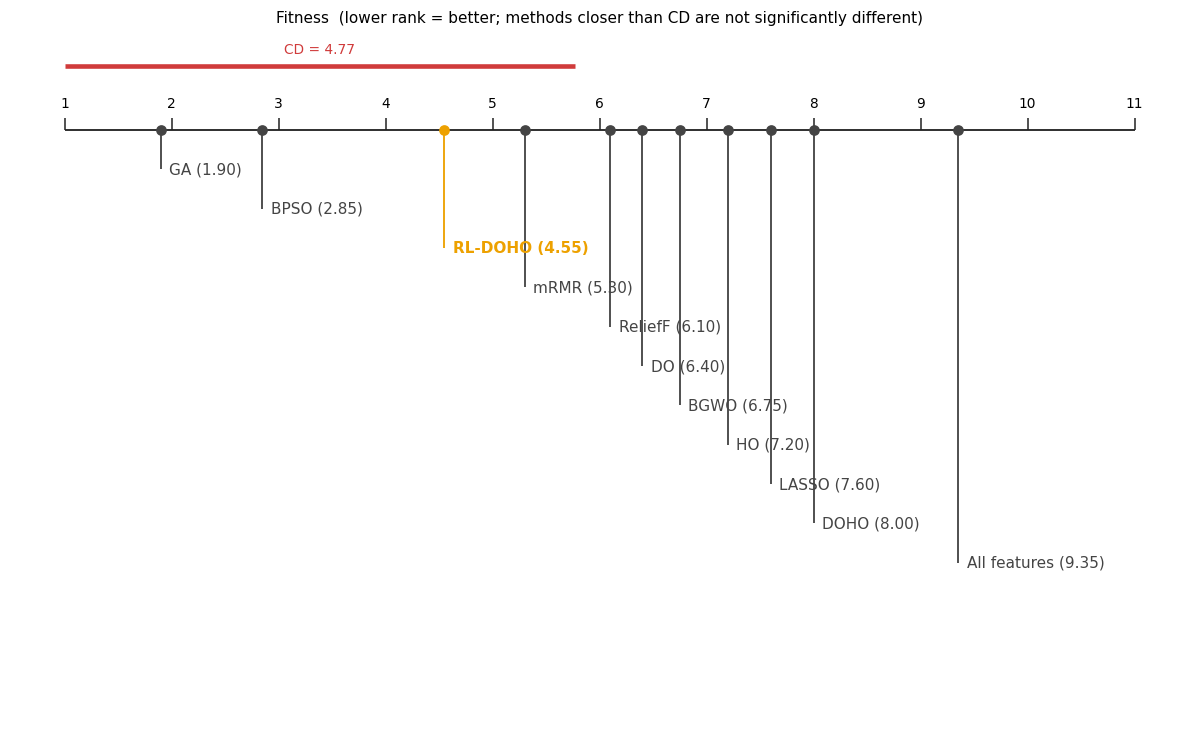

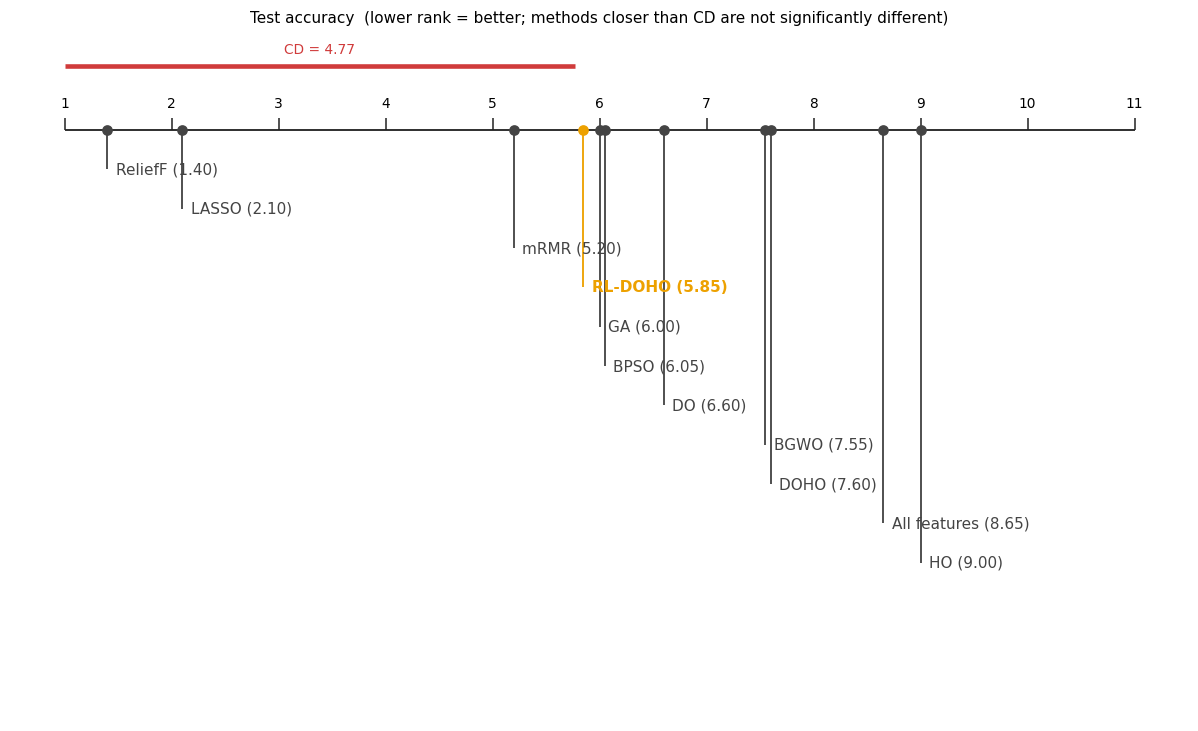

np.float64(4.7745485859921875)

In [14]:
# Critical-difference diagram (Nemenyi, alpha = 0.05) on average fitness rank over the 10 seeds
Q05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164, 11: 3.219, 12: 3.268}
def cd_diagram(avg_ranks, n_blocks, title, fname):
    k = len(avg_ranks); cd = Q05[k] * np.sqrt(k * (k + 1) / (6 * n_blocks))
    r = avg_ranks.sort_values()
    fig, ax = plt.subplots(figsize=(11, 0.45 * k + 1.8)); ax.grid(False)
    ax.set_xlim(0.5, k + 0.5); ax.set_ylim(-k - 1, 2); ax.axis("off")
    ax.hlines(0, 1, k, color="#222", lw=1.2)
    for x in range(1, k + 1):
        ax.vlines(x, 0, 0.25, color="#222", lw=1); ax.text(x, 0.45, str(x), ha="center", fontsize=9)
    ax.hlines(1.3, 1, 1 + cd, color="#d03b3b", lw=3); ax.text(1 + cd / 2, 1.55, f"CD = {cd:.2f}", ha="center", color="#d03b3b", fontsize=9)
    for i, (name, v) in enumerate(r.items()):
        y = -(i + 1) * 0.8; col = "#eda100" if name == PROPOSED else "#444"
        ax.vlines(v, y, 0, color=col, lw=1.2); ax.plot(v, 0, "o", color=col, ms=6)
        ax.text(v + 0.08, y, f"{name} ({v:.2f})", va="center", fontsize=10, color=col, fontweight="bold" if name == PROPOSED else None)
    ax.set_title(title + "  (lower rank = better; methods closer than CD are not significantly different)", fontsize=10)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", bbox_inches="tight"); plt.show()
    return cd

cd_diagram(res.groupby("method")["rank_fit"].mean(), len(SEEDS), "Fitness", "b1_cd_fitness.png")
cd_diagram(res.groupby("method")["rank_acc"].mean(), len(SEEDS), "Test accuracy", "b2_cd_test_acc.png")

## 10. Plots: test metrics and number of tests per method

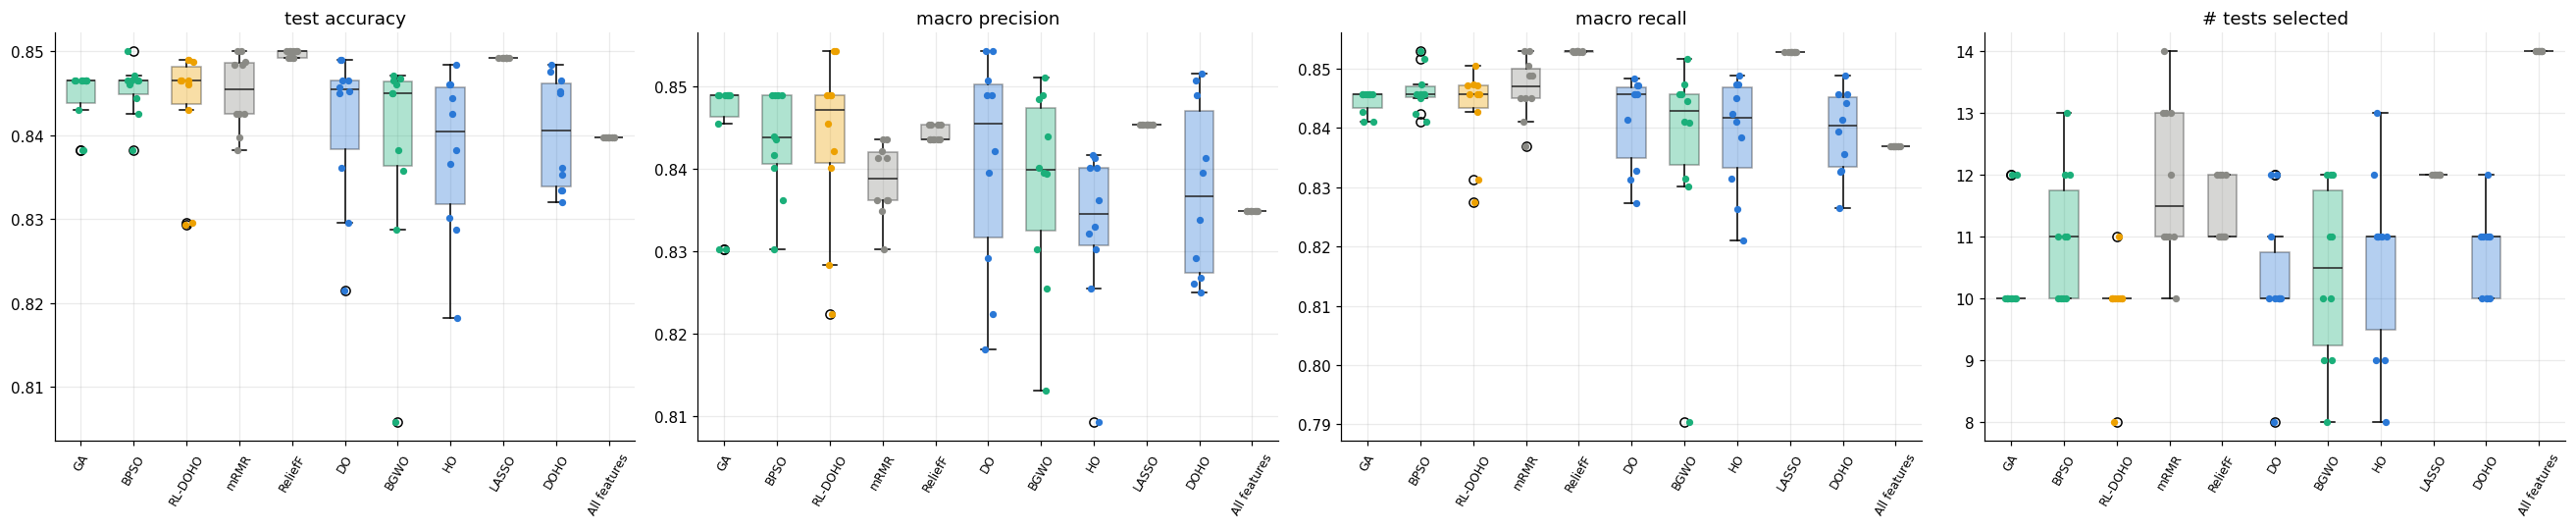

Colours: orange = RL-DOHO, blue = DO/HO/DOHO, green = GA/BPSO/BGWO, grey = filter methods / all features


In [15]:
order = list(tab.index)
pal = {m: ("#eda100" if m == PROPOSED else "#2a78d6" if m in ALGOS else "#1baf7a" if m in BASELINE_RUNNERS else "#8a8a85") for m in order}
fig, ax = plt.subplots(1, 4, figsize=(24, 5))
jit = np.random.default_rng(0)
for k, (col, title) in enumerate([("test_acc", "test accuracy"), ("test_prec", "macro precision"), ("test_rec", "macro recall"), ("n_feats", "# tests selected")]):
    data = [res[res.method == m][col].values for m in order]
    bp = ax[k].boxplot(data, widths=0.55, patch_artist=True, medianprops=dict(color="#222"))
    for patch, m in zip(bp["boxes"], order): patch.set_facecolor(pal[m]); patch.set_alpha(0.35)
    for i, (d, m) in enumerate(zip(data, order)):
        ax[k].scatter(i + 1 + jit.uniform(-0.12, 0.12, len(d)), d, color=pal[m], s=14, zorder=3)
    ax[k].set_xticks(range(1, len(order) + 1)); ax[k].set_xticklabels(order, rotation=60, fontsize=8); ax[k].set_title(title)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/b3_metrics_boxplots.png", bbox_inches="tight"); plt.show()
print("Colours: orange = RL-DOHO, blue = DO/HO/DOHO, green = GA/BPSO/BGWO, grey = filter methods / all features")

## 11. Which lab tests does each method select? (selection frequency over 10 seeds)

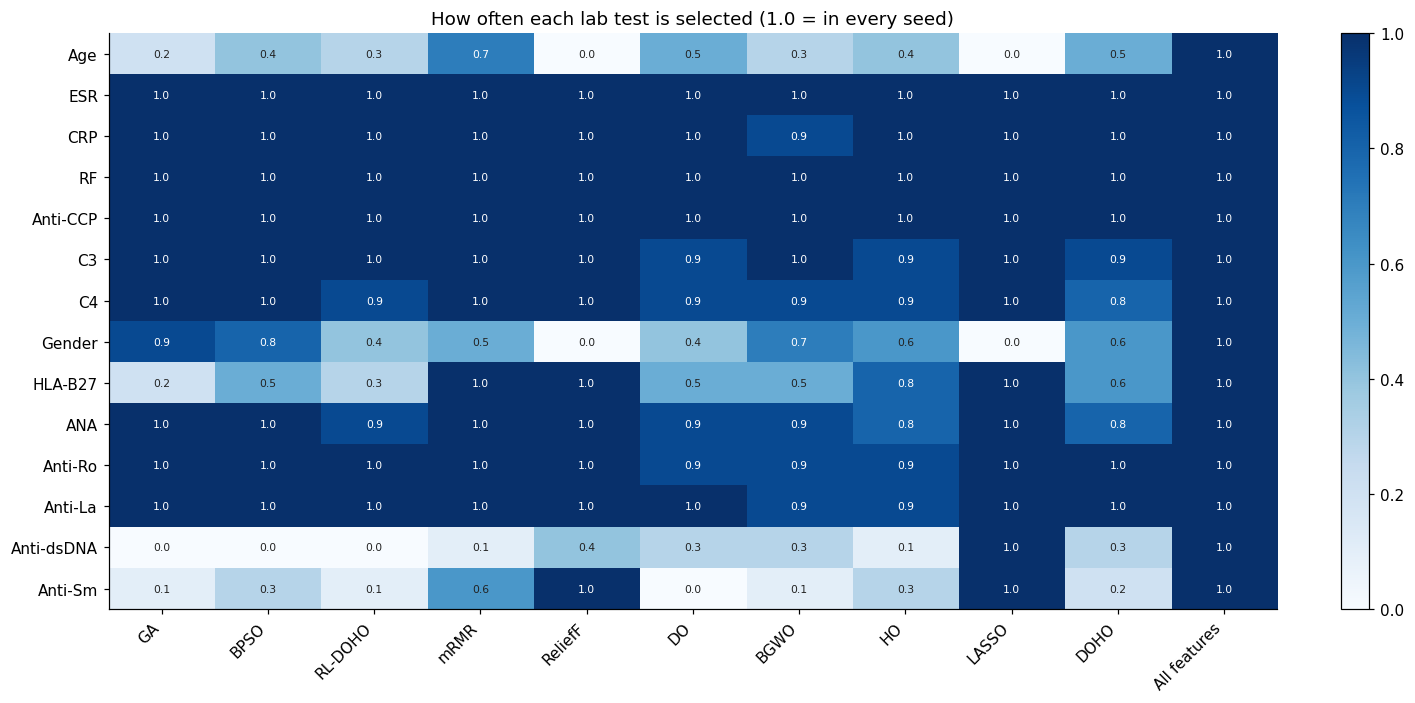

In [16]:
freq = pd.DataFrame({m: np.mean([runs[(m, s)]["mask"] for s in SEEDS], axis=0) for m in order}, index=FEATURES)
fig, ax = plt.subplots(figsize=(13, 6.5))
im = ax.imshow(freq.values, cmap="Blues", vmin=0, vmax=1, aspect="auto"); ax.grid(False)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha="right"); ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(order)):
        v = freq.values[i, j]; ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7, color="white" if v > 0.6 else "#222")
ax.set_title("How often each lab test is selected (1.0 = in every seed)"); plt.colorbar(im, fraction=0.03)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/b4_feature_frequency.png", bbox_inches="tight"); plt.show()
freq.round(2).to_csv(f"{OUT_DIR}/baselines_feature_frequency.csv")

## 12. Optimiser runtime
All search methods use the same number of fitness evaluations, so wall-clock time is dominated by model training. This measures each optimiser's own overhead.

In [17]:
# Optimiser overhead: every method gets the same number of fitness evaluations, so total runtime is dominated by
# model training. To compare the algorithms themselves, time each search method with an instant dummy fitness.
_real_fitness = fitness_function
_dummy_rng = np.random.default_rng(0)
def fitness_function(mask, *a):
    return float(np.sum(mask)) / len(mask) * 0.1 + _dummy_rng.random() * 0.01
over = []
for a in SEARCH:
    fn = RUNNERS.get(a) or BASELINE_RUNNERS[a]
    for s in range(3):
        t0 = time.perf_counter(); fn(seed=s, verbose=False); over.append({"method": a, "ms": 1000 * (time.perf_counter() - t0)})
fitness_function = _real_fitness
overhead = pd.DataFrame(over).groupby("method")["ms"].mean().reindex(SEARCH).round(1)
print("Optimiser overhead per run, excluding fitness evaluations (ms):"); print(overhead.to_string())

Optimiser overhead per run, excluding fitness evaluations (ms):
method
DO         129.7
HO          59.3
DOHO        58.7
RL-DOHO     65.4
GA          58.5
BPSO        56.2
BGWO        77.2


## 13. Summary

In [18]:
summ = pd.DataFrame({"avg rank (fitness)": res.groupby("method")["rank_fit"].mean(),
                     "avg rank (test acc)": res.groupby("method")["rank_acc"].mean(),
                     "test acc": res.groupby("method")["test_acc"].mean(), "macro-F1": res.groupby("method")["test_f1"].mean(),
                     "tests": res.groupby("method")["n_feats"].mean()}).sort_values("avg rank (fitness)")
print(summ.round(4).to_string())
print(f"\nAll results, figures and CSVs are in: {OUT_DIR}")

              avg rank (fitness)  avg rank (test acc)  test acc  macro-F1  tests
method                                                                          
GA                          1.90                 6.00    0.8445    0.8386   10.4
BPSO                        2.85                 6.05    0.8454    0.8406   11.0
RL-DOHO                     4.55                 5.85    0.8434    0.8379    9.9
mRMR                        5.30                 5.20    0.8451    0.8415   11.9
ReliefF                     6.10                 1.40    0.8497    0.8476   11.4
DO                          6.40                 6.60    0.8414    0.8365   10.3
BGWO                        6.75                 7.55    0.8385    0.8328   10.4
HO                          7.20                 9.00    0.8379    0.8332   10.6
LASSO                       7.60                 2.10    0.8492    0.8481   12.0
DOHO                        8.00                 7.60    0.8403    0.8346   10.7
All features                